In [1]:
!pip install git+https://github.com/JamorMoussa/keratorch.git

  Cloning https://github.com/JamorMoussa/keratorch.git to /tmp/pip-req-build-dv1dq6tc
  Running command git clone --filter=blob:none --quiet https://github.com/JamorMoussa/keratorch.git /tmp/pip-req-build-dv1dq6tc
  Resolved https://github.com/JamorMoussa/keratorch.git to commit b051ad6c80345490f8f376d8587312ef70137622
  Preparing metadata (setup.py) ... done
  Created wheel for keratorch: filename=keratorch-0.0.1-py3-none-any.whl size=6050 sha256=984ab79510b1411d331b8629f9e927d4bb002ce9729827977b11aa8747f576ff
  Stored in directory: /tmp/pip-ephem-wheel-cache-y4o61j21/wheels/92/7f/94/34475bcf38ef6f5980da5eb3ce78ff6ebdd8aebb2d30325b80
Successfully built keratorch


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms


import keratorch as kt

In [286]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


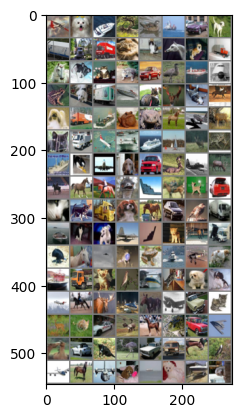

plane dog   ship  deer  bird  ship  car   dog   truck truck truck cat   cat   horse dog   truck horse dog   cat   cat   car   bird  ship  plane frog  dog   truck ship  cat   deer  cat   horse dog   truck ship  frog  frog  horse plane deer  cat   truck plane ship  ship  ship  deer  frog  ship  dog   plane dog   car   deer  plane deer  horse horse horse bird  plane horse dog   car   cat   dog   truck dog   horse car   bird  truck ship  cat   horse plane plane cat   horse truck bird  horse plane frog  frog  ship  plane dog   ship  truck dog   bird  ship  cat   dog   dog   plane horse deer  plane deer  plane car   cat   deer  cat   car   deer  horse frog  car   plane horse car   cat   bird  car   truck horse bird  plane horse plane dog   ship  dog   ship  dog  


In [287]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [288]:
# class Net(kt.nn.ktModule):
#     def __init__(self):
#         super().__init__()
#         self.conv1 = nn.Conv2d(3, 6, 5)
#         self.pool = nn.MaxPool2d(2, 2)
#         self.conv2 = nn.Conv2d(6, 16, 5)
#         self.fc1 = nn.Linear(16 * 5 * 5, 120)
#         self.fc2 = nn.Linear(120, 84)
#         self.fc3 = nn.Linear(84, 10)

#     def forward(self, x):
#         x = self.pool(F.relu(self.conv1(x)))
#         x = self.pool(F.relu(self.conv2(x)))
#         x = torch.flatten(x, 1) # flatten all dimensions except batch
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         x = self.fc3(x)
#         return x

In [289]:
# net = Net()

In [290]:
def log(x):
  print(x.shape)
  return x

In [291]:
net = kt.nn.Sequential(
            nn.Conv2d(3, 6, 3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(6, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 84),
            nn.ReLU(),
            nn.Linear(84, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )

In [292]:
net

Sequential(
  (0): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1152, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=84, bias=True)
  (10): ReLU()
  (11): Linear(in_features=84, out_features=32, bias=True)
  (12): ReLU()
  (13): Linear(in_features=32, out_features=10, bias=True)
)

In [293]:
1152/9

128.0

In [294]:
net(x).shape

torch.Size([16, 10])

In [295]:
criterion = nn.CrossEntropyLoss()
optimizer = kt.optim.Adam(lr=0.001)

In [296]:
net.compile(
  loss_fn= criterion,
  optimizer= optimizer,
  callbacks= [
      kt.callbacks.LossCallBack(),
  ],
  device= torch.device("cuda")
)

In [297]:
hist = net.fit(trainloader= trainloader, num_iters=10, verbose_iter=500)

100%|██████████| 391/391 [00:13<00:00, 28.94it/s]


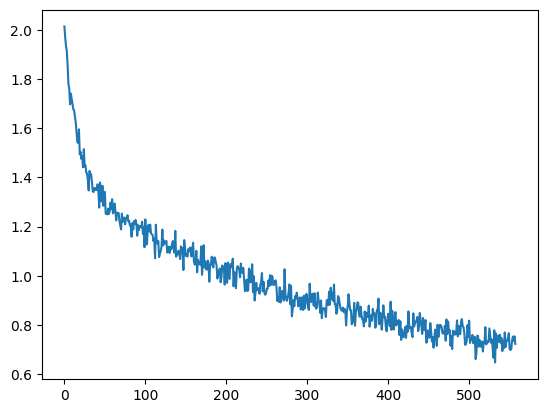

In [298]:
plt.plot(hist.history["train_loss"])

In [299]:
def compute_accuracy(model, loader: torch.utils.data.DataLoader):
  acc = 0
  for x, y in loader:
    res = model(x.to("cuda")).argmax(dim=1)
    acc += (res.detach().cpu() == y).sum()

  acc = acc.item()/len(loader)
  return acc/loader.batch_size

In [300]:
compute_accuracy(
    model=net,
    loader= trainloader
)

0.7082800511508951

In [301]:
compute_accuracy(
    model=net,
    loader= testloader
)

0.6459651898734177